In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Loading dataset
df = pd.read_csv('final_dataset.csv')

## 3.1 — Has remotizability changed after COVID?

We now examine whether the occupational structure of EU countries shifted towards more remotizable jobs after the pandemic. We compare 2018 and 2023 and focus on differences across geographic regions.

Average remotizability index by year:


,TIME_PERIOD,remotizability_index
0,2017,34.12
1,2018,34.35
2,2019,34.68
3,2020,35.46
4,2021,35.99
5,2022,36.06
6,2023,36.17



Change in remotizability index by region (2018 -> 2023, percentage points):


TIME_PERIOD,2018,2023,delta_pp
regione,,,
Est,30.32,32.62,230.27
Nord/Ovest,38.77,40.90,212.70
Sud,33.37,34.24,86.54



Top 10 countries with the largest increase in remotizability (pp):


TIME_PERIOD,nome_paese,regione,2018,2023,delta_pp
26,Slovakia,Est,0.291,0.329,3.820
21,Poland,Est,0.316,0.351,3.440
17,Luxembourg,Nord/Ovest,0.446,0.477,3.179
20,Netherlands,Nord/Ovest,0.410,0.442,3.176
16,Lithuania,Est,0.329,0.360,3.003
24,Sweden,Nord/Ovest,0.406,0.434,2.863
14,Ireland,Nord/Ovest,0.375,0.402,2.730
13,Hungary,Est,0.291,0.318,2.724
11,France,Nord/Ovest,0.362,0.387,2.485
22,Portugal,Sud,0.320,0.341,2.164


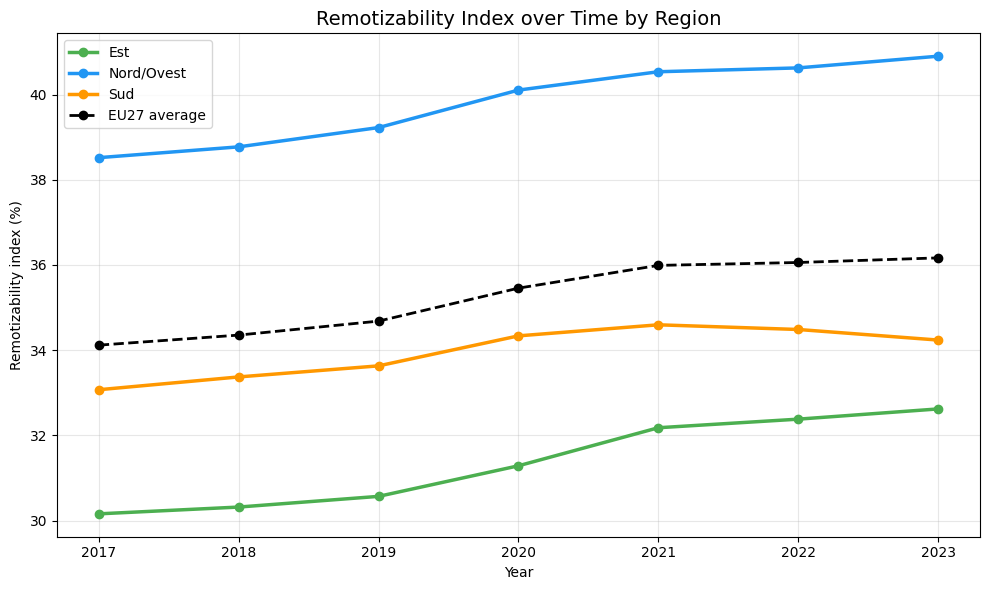

In [11]:
# Average by year and region

ri_region_year = (
    df.groupby(['TIME_PERIOD', 'regione'])['remotizability_index']
      .mean()
      .reset_index()
)

# Overall average by year
ri_total_year = (
    df.groupby('TIME_PERIOD')['remotizability_index']
      .mean()
      .reset_index()
)

# Country-level change from 2018 to 2023
ri_country_change = (
    df[df['TIME_PERIOD'].isin([2018, 2023])]
    .pivot_table(index=['geo', 'nome_paese', 'regione'],
                 columns='TIME_PERIOD',
                 values='remotizability_index')
    .reset_index()
)

ri_country_change['delta_pp'] = (ri_country_change[2023] - ri_country_change[2018]) * 100
ri_country_change = ri_country_change.sort_values('delta_pp', ascending=False)

# Average regional change
ri_region_change = (
    df[df['TIME_PERIOD'].isin([2018, 2023])]
    .groupby(['regione', 'TIME_PERIOD'])['remotizability_index']
    .mean()
    .unstack()
)

ri_region_change['delta_pp'] = (ri_region_change[2023] - ri_region_change[2018]) * 100

print("Average remotizability index by year:")
display((ri_total_year.assign(remotizability_index=lambda x: x['remotizability_index'] * 100)).round(2))

print("\nChange in remotizability index by region (2018 -> 2023, percentage points):")
display((ri_region_change * 100).round(2))

print("\nTop 10 countries with the largest increase in remotizability (pp):")
display(ri_country_change[['nome_paese', 'regione', 2018, 2023, 'delta_pp']].round(3).head(10))

# Plot
REGION_COLORS = {'Nord/Ovest': '#2196F3', 'Sud': '#FF9800', 'Est': '#4CAF50'}

plt.figure(figsize=(10, 6))
for region in ri_region_year['regione'].unique():
    temp = ri_region_year[ri_region_year['regione'] == region]
    plt.plot(
        temp['TIME_PERIOD'],
        temp['remotizability_index'] * 100,
        marker='o',
        linewidth=2.5,
        label=region,
        color=REGION_COLORS[region]
    )

plt.plot(
    ri_total_year['TIME_PERIOD'],
    ri_total_year['remotizability_index'] * 100,
    marker='o',
    linestyle='--',
    linewidth=2,
    color='black',
    label='EU27 average'
)

plt.title('Remotizability Index over Time by Region', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Remotizability index (%)')
plt.xticks(sorted(df['TIME_PERIOD'].unique()))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The average remotizability index in the EU27 increases from 34.35% in 2018 to 36.17% in 2023, corresponding to an overall rise of about 1.81 percentage points. The increase is visible in all macro-regions, but with different intensity: Eastern Europe records the largest increase (+2.30 pp), followed by North/West (+2.13 pp), while Southern Europe grows much less (+0.87 pp). 

This suggests that, after the pandemic, the occupational structure of European labour markets shifted towards jobs that are more compatible with remote work, but in an uneven way. In particular, Southern Europe appears to have benefited less from this structural transformation.

## 3.2 — Productivity over time and the 2020 paradox

We analyze the evolution of labour productivity across regions to understand whether the pandemic altered the composition of economic activity. A particularly interesting question is whether productivity increased during the COVID shock.

Average productivity index by year:


,TIME_PERIOD,indice_produttivita
0,2017,110.67
1,2018,112.46
2,2019,114.00
3,2020,116.83
4,2021,120.08
5,2022,120.07
6,2023,119.45



Productivity change from 2019 to 2020 by region:


TIME_PERIOD,2019,2020,delta_2019_2020,pct_change_2019_2020
regione,,,,
Est,125.78,129.15,3.37,2.68
Nord/Ovest,109.42,113.67,4.25,3.89
Sud,106.46,106.92,0.46,0.44


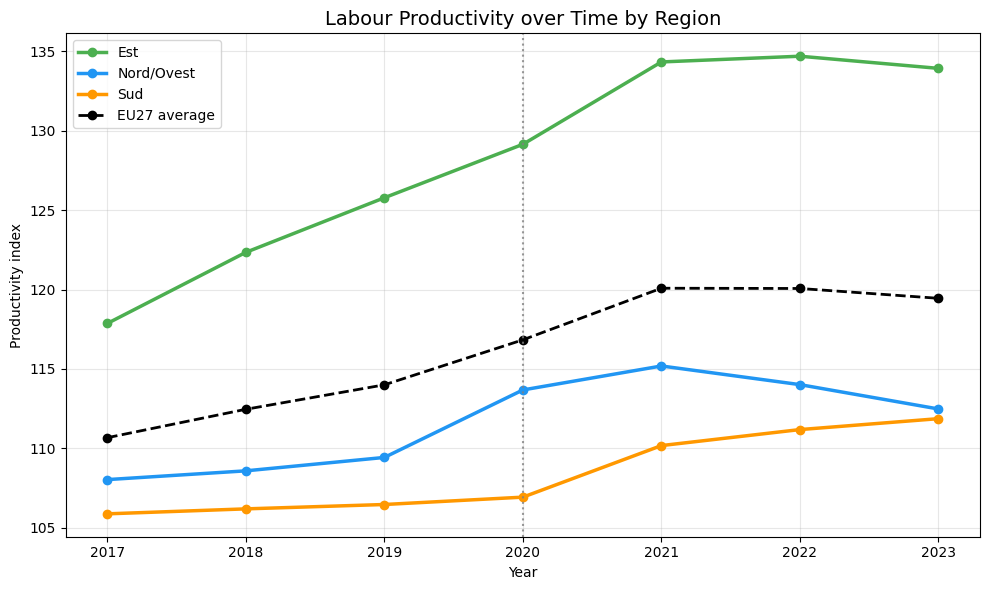

In [8]:
prod_region_year = (
    df.groupby(['TIME_PERIOD', 'regione'])['indice_produttivita']
      .mean()
      .reset_index()
)

prod_total_year = (
    df.groupby('TIME_PERIOD')['indice_produttivita']
      .mean()
      .reset_index()
)

# Change from 2019 to 2020
prod_2019_2020 = (
    df[df['TIME_PERIOD'].isin([2019, 2020])]
    .groupby(['regione', 'TIME_PERIOD'])['indice_produttivita']
    .mean()
    .unstack()
)

prod_2019_2020['delta_2019_2020'] = prod_2019_2020[2020] - prod_2019_2020[2019]
prod_2019_2020['pct_change_2019_2020'] = ((prod_2019_2020[2020] / prod_2019_2020[2019]) - 1) * 100

print("Average productivity index by year:")
display(prod_total_year.round(2))

print("\nProductivity change from 2019 to 2020 by region:")
display(prod_2019_2020.round(2))

plt.figure(figsize=(10, 6))
for region in prod_region_year['regione'].unique():
    temp = prod_region_year[prod_region_year['regione'] == region]
    plt.plot(
        temp['TIME_PERIOD'],
        temp['indice_produttivita'],
        marker='o',
        linewidth=2.5,
        label=region,
        color=REGION_COLORS[region]
    )

plt.plot(
    prod_total_year['TIME_PERIOD'],
    prod_total_year['indice_produttivita'],
    marker='o',
    linestyle='--',
    linewidth=2,
    color='black',
    label='EU27 average'
)

plt.axvline(x=2020, linestyle=':', color='gray', alpha=0.8)
plt.title('Labour Productivity over Time by Region', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Productivity index')
plt.xticks(sorted(df['TIME_PERIOD'].unique()))
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Average labour productivity in the EU27 rises from 114.00 in 2019 to 116.83 in 2020, despite the recession. This pattern is especially visible in Eastern Europe and in the North/West, while the increase is more limited in the South. 

At first glance, this finding may seem surprising, since 2020 was a year of severe economic disruption. However, the increase in average productivity does not necessarily mean that each worker or firm became more efficient during the pandemic. A more plausible explanation is a composition effect. The sectors that were hit hardest by lockdowns and mobility restrictions were often those where remote work was less feasible and productivity levels were relatively lower, such as hospitality, tourism, and many face-to-face services. By contrast, sectors that could continue operating through digital tools and remote work arrangements were generally more skill-intensive and more productive on average. As a result, the workers who remained active were disproportionately concentrated in higher-productivity activities, which mechanically increased the aggregate productivity index. In this sense, the 2020 rise in productivity should be interpreted not as a generalized efficiency gain, but rather as a shift in the composition of employment and output during the COVID shock.

## 3.3 — Convergence or divergence across European regions?

Finally, we study whether regional disparities in remotizability are narrowing or widening over time. This helps assess whether the pandemic accelerated structural convergence within the EU.

Regional gaps in remotizability index (percentage points):


regione,gap_NW_East_pp,gap_NW_South_pp,gap_South_East_pp
TIME_PERIOD,,,
2017,8.36,5.45,2.91
2018,8.45,5.40,3.05
2019,8.66,5.59,3.06
2020,8.82,5.77,3.05
2021,8.35,5.94,2.42
2022,8.24,6.14,2.10
2023,8.28,6.66,1.62


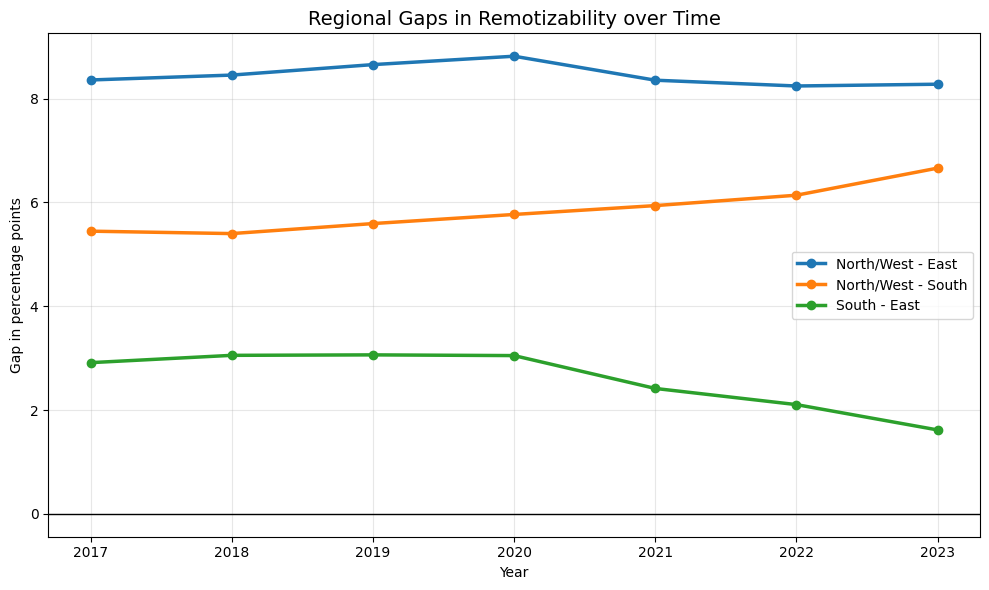

In [9]:
ri_wide = (
    df.groupby(['TIME_PERIOD', 'regione'])['remotizability_index']
      .mean()
      .unstack()
)

ri_wide['gap_NW_East_pp'] = (ri_wide['Nord/Ovest'] - ri_wide['Est']) * 100
ri_wide['gap_NW_South_pp'] = (ri_wide['Nord/Ovest'] - ri_wide['Sud']) * 100
ri_wide['gap_South_East_pp'] = (ri_wide['Sud'] - ri_wide['Est']) * 100

print("Regional gaps in remotizability index (percentage points):")
display(ri_wide[['gap_NW_East_pp', 'gap_NW_South_pp', 'gap_South_East_pp']].round(2))

gap_plot = ri_wide[['gap_NW_East_pp', 'gap_NW_South_pp', 'gap_South_East_pp']].reset_index()

plt.figure(figsize=(10, 6))
plt.plot(gap_plot['TIME_PERIOD'], gap_plot['gap_NW_East_pp'], marker='o', linewidth=2.5, label='North/West - East')
plt.plot(gap_plot['TIME_PERIOD'], gap_plot['gap_NW_South_pp'], marker='o', linewidth=2.5, label='North/West - South')
plt.plot(gap_plot['TIME_PERIOD'], gap_plot['gap_South_East_pp'], marker='o', linewidth=2.5, label='South - East')

plt.title('Regional Gaps in Remotizability over Time', fontsize=14)
plt.xlabel('Year')
plt.ylabel('Gap in percentage points')
plt.xticks(sorted(df['TIME_PERIOD'].unique()))
plt.axhline(0, color='black', linewidth=1)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

The data point to partial, rather than full, convergence. 
- The gap between Southern and Eastern Europe narrows substantially, from 3.05 percentage points in 2018 to 1.62 in 2023, suggesting that Eastern Europe is catching up relatively quickly. 
- By contrast, the gap between North/West and East remains large, moving only from 8.45 to 8.28 points. 
- At the same time, the gap between North/West and South widens, from 5.40 to 6.66 points. 

Overall, this suggests that Eastern Europe is gradually moving closer to the middle of the European distribution, while Southern Europe risks remaining further behind in the transition towards more remotizable occupations.